# 05 · Model training

LightGBM trained on 2015–2021, tuned on 2022 over a fixed grid; isotonic calibration on 2022.

In [1]:
import sys, json
from pathlib import Path
ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT))
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from src import config
M = config.METRICS_DIR
def load(name):
    p = M / f"{name}.json"
    return json.loads(p.read_text()) if p.exists() else None
plt.rcParams.update({"figure.dpi": 110, "axes.spines.top": False, "axes.spines.right": False,
                     "axes.grid": True, "grid.color": "#e1e0d9", "axes.edgecolor": "#c3c2b7"})
C1, C2, C3 = "#2a78d6", "#eb6834", "#1baf7a"


In [2]:
p = json.loads((config.PROCESSED / "models/m1_params.json").read_text())
print({k: v for k, v in p.items() if k not in ("trials", "features")})
pd.DataFrame(p["trials"]).sort_values("val_precision_at_20", ascending=False)

{'params': {'num_leaves': 15, 'min_child_samples': 200, 'learning_rate': 0.1}, 'num_boost_round': 141, 'train_rows': 116447, 'train_positive_rate': 0.06482777572629608, 'val_rows': 21798, 'val_precision_at_20': 0.4, 'val_pr_auc': 0.47747815989722103}


,num_leaves,min_child_samples,learning_rate,best_iteration,val_precision_at_20,val_pr_auc
3,15,200,0.10,141,0.400000,0.477478
6,31,200,0.03,286,0.394643,0.473352
5,31,50,0.10,138,0.392857,0.475798
4,31,50,0.03,493,0.389286,0.479540
0,15,50,0.03,764,0.382143,0.469903
1,15,50,0.10,215,0.376786,0.446580
2,15,200,0.03,730,0.375000,0.469038
8,63,50,0.03,282,0.371429,0.464566
10,63,200,0.03,283,0.369643,0.453798
7,31,200,0.10,137,0.364286,0.460425


In [3]:
print(json.dumps(load("baselines_val_2022"), indent=1))

{
 "B0_persistence": {
  "precision_at_k": 0.0375,
  "precision_at_k_monsoon": 0.004166666666666667,
  "n_dates": 28,
  "n_dates_monsoon": 12,
  "pr_auc": 0.04433889724533346,
  "major": {
   "hits": 9,
   "total": 753,
   "recall": 0.01195219123505976
  }
 },
 "B1_history": {
  "precision_at_k": 0.08571428571428572,
  "precision_at_k_monsoon": 0.016666666666666666,
  "n_dates": 28,
  "n_dates_monsoon": 12,
  "pr_auc": 0.050437265991733,
  "major": {
   "hits": 29,
   "total": 753,
   "recall": 0.03851261620185923
  }
 }
}


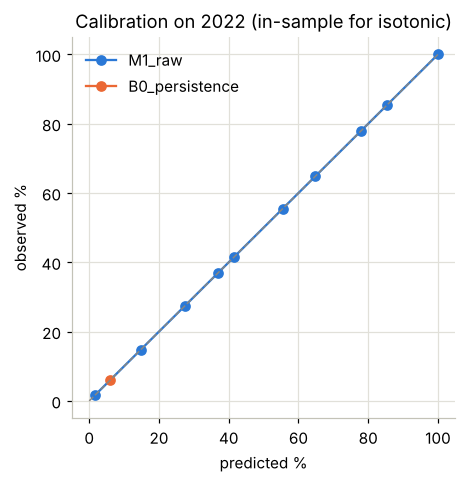

In [4]:
cal = load("calibration_val_2022")
fig, ax = plt.subplots(figsize=(4.5, 4.5))
for name, c in (("M1_raw", C1), ("B0_persistence", C2)):
    r = pd.DataFrame(cal[name]["reliability_val"])
    ax.plot(r.mean_pred * 100, r.observed * 100, marker="o", color=c, lw=1.5, label=name)
ax.plot([0, 100], [0, 100], ls="--", color="#898781", lw=1)
ax.set_xlabel("predicted %"); ax.set_ylabel("observed %"); ax.legend(frameon=False); ax.set_title("Calibration on 2022 (in-sample for isotonic)")
plt.show()